<img src="https://www.fciencias.unam.mx/sites/default/files/logoFC_2.png" width="500" align="left"/>
<p align="right">
<b>Lingüística Computacional</b>
<br><b>Práctica 2 Propiedades estadísticas del lenguaje y Diversidad</b>
<br><b>Profesora:</b> Dra. Ximena Gutiérrez Vasques
<br><b>Ayudante Teo:</b> Ximena de la Luz Contreras Mendoza
<br><b>Ayudante Lab:</b> Diego Alberto Barriga Martínez
<br><b>Alumna:</b> Ortega Hernández Zaira Daniela
<br><b>Marzo, 2026</b>
</p>

##**Práctica 2 Propiedades estadísticas del lenguaje y Diversidad**


##**1. Verificación empírica de la Ley de Zipf**

Verificar si la ley de Zipf se cumple en los siguientes casos:
#
1. En un lenguaje artificial creado por ustedes.
    * Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido.
        * **Nota:** Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.
    * Obtengan las frecuencias de las palabras generadas para este texto artificial
2. Alguna lengua de bajos recursos digitales (*low-resourced language*)
     * Busca un corpus de libre acceso en alguna lengua de bajos recursos digitales
     * Obten las frecuencias de sus palabras

 En ambos casos realiza lo siguiente:
 * Estima el parámetro $\alpha$ que mejor se ajuste a la curva
 * Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).
     * Incluye la recta aproximada por $\alpha$
 * ¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.

 > [!TIP]
> Puedes utilizar los corpus del paquete [`py-elotl`](https://pypi.org/project/elotl/)


La Ley de Zipf establece que la frecuencia de una palabra ($f(w_r)$) es inversamente proporcional a su rango ($r$) en la distribución de frecuencias: $f(w_r) \propto \frac{1}{r^\alpha}$, donde $\alpha$ típicamente está entre 1 y 2 para lenguas naturales (Manning & Schütze, 1999). Verificaremos esta ley en un lenguaje artificial y en una lengua de bajos recursos digitales.


## **Generación del corpus artificial**

In [10]:
import requests
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
import re


def generar_texto_artificial(longitud=100000, alfabeto=None, prob_caracteres=None):
    """
    Genera texto artificial seleccionando caracteres al azar de un alfabeto definido.

    Parámetros:
    -----------
    longitud : int
        Número total de caracteres a generar
    alfabeto : list
        Lista de caracteres permitidos (incluye espacio)
    prob_caracteres : list
        Probabilidades asociadas a cada carácter (normalizadas)

    Retorna:
    --------
    str : Texto generado
    """
    if alfabeto is None:
        # Alfabeto simple: letras minúsculas + espacio
        alfabeto = ['a', 'b', 'c', 'd', 'e', ' ', ' ', ' ']  # Espacio con mayor probabilidad

    if prob_caracteres is None:
        # Distribución sesgada: espacio más frecuente, vocales más que consonantes
        prob_caracteres = [0.15, 0.10, 0.12, 0.08, 0.20, 0.15, 0.10, 0.10]
        prob_caracteres = np.array(prob_caracteres) / np.sum(prob_caracteres)

    texto = ''.join(np.random.choice(alfabeto, size=longitud, p=prob_caracteres))
    return texto

# Generamos corpus artificial
print("Generando corpus artificial...")
texto_artificial = generar_texto_artificial(longitud=100000)
palabras_artificiales = texto_artificial.split()

print(f"Tokens totales: {len(palabras_artificiales)}")
print(f"Tipos únicos: {len(set(palabras_artificiales))}")
print("\n10 palabras más frecuentes:")
counter_artificial = Counter(palabras_artificiales)
print(counter_artificial.most_common(10))

Generando corpus artificial...
Tokens totales: 22693
Tipos únicos: 4388

10 palabras más frecuentes:
[('e', 2483), ('a', 1828), ('c', 1457), ('b', 1248), ('d', 971), ('ee', 496), ('ae', 379), ('ea', 367), ('aa', 288), ('ec', 280)]


##**Análisis de frecuencias y estimación de α**

In [11]:
def analizar_zipf(corpus_counter, nombre_corpus="Corpus"):
    """
    Analiza la distribución de frecuencias y estima el parámetro α de Zipf.
    """
    df_freq = pd.DataFrame.from_dict(corpus_counter, orient='index', columns=['freq']).reset_index()
    df_freq.columns = ['palabra', 'freq']
    df_freq.sort_values('freq', ascending=False, inplace=True)

    # Ranks (empezando desde 1)
    ranks = np.arange(1, len(df_freq) + 1)
    frequencies = df_freq['freq'].values

    return df_freq, ranks, frequencies

def estimar_alpha_zipf(ranks, frequencies):
    """
    Estima el parámetro α minimizando el error cuadrático medio.

    Referencia: Basado en regresión lineal log-log (Manning & Schütze, 1999)
    """
    def objective(alpha):
        predicted_log_freq = np.log(frequencies[0]) - alpha * np.log(ranks)
        return np.sum((np.log(frequencies) - predicted_log_freq) ** 2)

    resultado = minimize(objective, x0=1.0, method='BFGS')
    alpha_estimado = resultado.x[0]
    mse = resultado.fun

    return alpha_estimado, mse

# Análisis del corpus artificial
df_artificial, ranks_artificial, freqs_artificial = analizar_zipf(counter_artificial, "Artificial")
alpha_artificial, mse_artificial = estimar_alpha_zipf(ranks_artificial, freqs_artificial)

print(f"\n=== CORPUS ARTIFICIAL ===")
print(f"α estimado: {alpha_artificial:.4f}")
print(f"MSE: {mse_artificial:.4f}")
print(f"Palabras analizadas: {len(df_artificial)}")


=== CORPUS ARTIFICIAL ===
α estimado: 1.0091
MSE: 807.7449
Palabras analizadas: 4388


## **Visualización del corpus artificial**

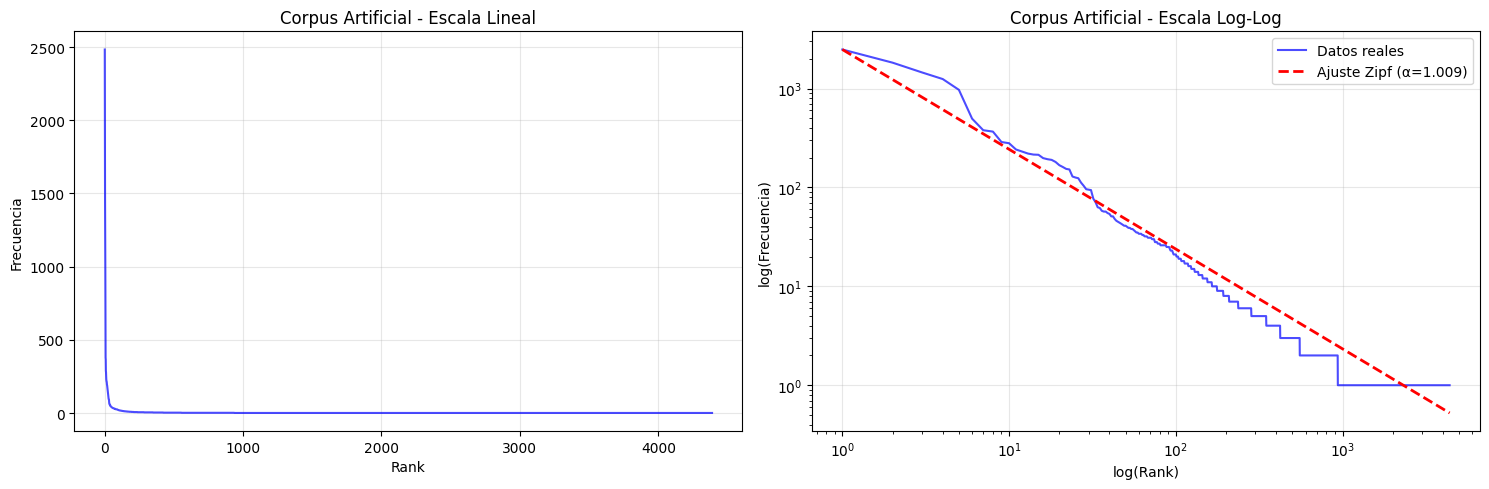

In [12]:
def plot_zipf(ranks, frequencies, alpha, nombre_corpus, max_words=10000):
    """
    Genera gráficas de la ley de Zipf (lineal y log-log).
    """
    plt.figure(figsize=(15, 5))

    # Gráfica lineal
    plt.subplot(1, 2, 1)
    plt.plot(ranks[:max_words], frequencies[:max_words], 'b-', alpha=0.7, label='Datos reales')
    plt.xlabel('Rank')
    plt.ylabel('Frecuencia')
    plt.title(f'{nombre_corpus} - Escala Lineal')
    plt.grid(True, alpha=0.3)

    # Gráfica log-log con aproximación
    plt.subplot(1, 2, 2)
    plt.loglog(ranks[:max_words], frequencies[:max_words], 'b-', alpha=0.7, label='Datos reales')

    # Línea de aproximación Zipf
    predicted = np.exp(np.log(frequencies[0]) - alpha * np.log(ranks[:max_words]))
    plt.loglog(ranks[:max_words], predicted, 'r--', linewidth=2, label=f'Ajuste Zipf (α={alpha:.3f})')

    plt.xlabel('log(Rank)')
    plt.ylabel('log(Frecuencia)')
    plt.title(f'{nombre_corpus} - Escala Log-Log')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualización
plot_zipf(ranks_artificial, freqs_artificial, alpha_artificial, "Corpus Artificial")

## **Náhuatl**
## **Instalación y verificación**

In [13]:
# Verificamos instalación
!pip install elotl

import elotl.corpus
print(" elotl importado correctamente")

# Listamos corpora disponibles
print("\n Corpora disponibles:")
list_of_corpus = elotl.corpus.list_of_corpus()
for row in list_of_corpus:
    print(f"  {row}")

 elotl importado correctamente

 Corpora disponibles:
  ['axolotl', 'Is a Spanish-Nahuatl parallel corpus']
  ['tsunkua', 'Is a Spanish-Otomí parallel corpus']
  ['kolo', 'Is a Spanish-Mixteco parallel corpus']


## **Carga de corpus NAHUATL (axolotl)**

In [14]:
# CARGAMOS NAHUATL (Spanish-Nahuatl parallel)
print("\n Cargando corpus NAHUATL (axolotl)...")
nahuatl_corpus = elotl.corpus.load('axolotl')

if nahuatl_corpus == 0:
    print(" Error: Corpus no encontrado")
else:
    print(f"Corpus cargado: {len(nahuatl_corpus)} oraciones")
    print("Ejemplo primera oración:")
    print(nahuatl_corpus[0])


 Cargando corpus NAHUATL (axolotl)...
Corpus cargado: 16111 oraciones
Ejemplo primera oración:
['Y así, cuando hizo su ofrenda de fuego, se sienta delante de los demás y una persona se queda junto a él.', 'Auh in ye yuhqui in on tlenamacac niman ye ic teixpan on motlalia ce tlacatl itech mocaua.', 'Classical Nahuatl', 'Vida económica de Tenochtitlan', 'nci']


## **Extracción de palabras Nahuatl**

In [15]:
def extraer_nahuatl(corpus):
    """
    Extrae SOLO palabras en náhuatl del corpus paralelo.
    Formato: [español, nahuatl, idioma, fuente, id]
    """
    palabras_nahuatl = []

    for oracion in corpus:
        if len(oracion) >= 5 and oracion[2] == 'Classical Nahuatl':
            # oracion[1] = texto en náhuatl
            texto_nahuatl = oracion[1]
            # Split por espacios, limpieza básica
            palabras = re.findall(r'\b\w+\b', texto_nahuatl.lower())
            palabras_nahuatl.extend(palabras)

    return palabras_nahuatl

# EXTRAEMOS
palabras_nahuatl = extraer_nahuatl(nahuatl_corpus)
palabras_nahuatl = [p for p in palabras_nahuatl if len(p) > 0]

print(f" Tokens NAHUATL:     {len(palabras_nahuatl):,}")
print(f" Tipos únicos:       {len(set(palabras_nahuatl)):,}")

# Contador de frecuencias
counter_nahuatl = Counter(palabras_nahuatl)
print("\n TOP 20 palabras más frecuentes (Náhuatl):")
for i, (palabra, freq) in enumerate(counter_nahuatl.most_common(20), 1):
    print(f"{i:2d}. '{palabra}' → {freq:4d}")

 Tokens NAHUATL:     136,128
 Tipos únicos:       26,209

 TOP 20 palabras más frecuentes (Náhuatl):
 1. 'yn' → 12423
 2. 'in' → 8325
 3. 'auh' → 3184
 4. 'ye' → 2392
 5. 'ca' → 1994
 6. 'ynic' → 1829
 7. 'yhuan' → 1323
 8. 'y' → 1256
 9. 'oncan' → 1189
10. 'xihuitl' →  980
11. 'niman' →  959
12. 'de' →  884
13. 'yc' →  815
14. 'ma' →  813
15. 'nican' →  798
16. 'zan' →  739
17. 'ypan' →  725
18. 'ipan' →  679
19. 'huel' →  670
20. 'ic' →  608


## **Análisis completo Nahuatl**


 LEY DE ZIPF - NÁHUATL-CLÁSICO (elotl)
α estimado:     0.9768
Error MSE:      2162.30
Tokens:         136,128
Tipos:          26,209
Palabra #1:     'yn'


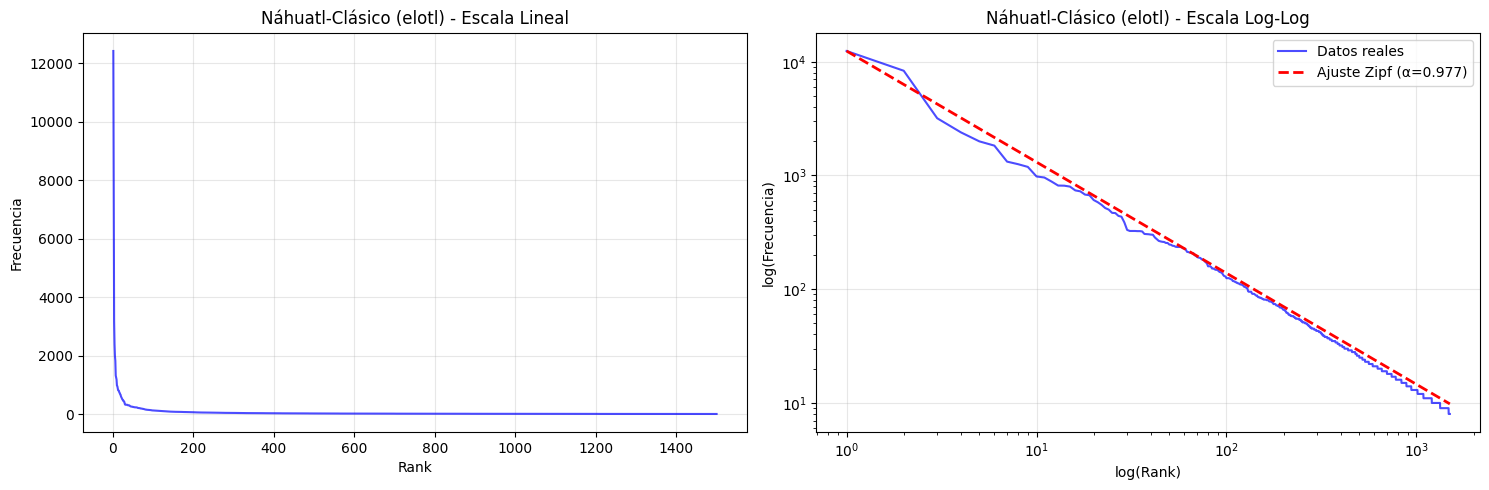

In [16]:
# ANÁLISIS ZIPF
df_nahuatl, ranks_nahuatl, freqs_nahuatl = analizar_zipf(counter_nahuatl, "Náhuatl (elotl)")
alpha_nahuatl, mse_nahuatl = estimar_alpha_zipf(ranks_nahuatl, freqs_nahuatl)

print("\n" + "="*60)
print(" LEY DE ZIPF - NÁHUATL-CLÁSICO (elotl)")
print("="*60)
print(f"α estimado:     {alpha_nahuatl:.4f}")
print(f"Error MSE:      {mse_nahuatl:.2f}")
print(f"Tokens:         {len(palabras_nahuatl):,}")
print(f"Tipos:          {len(counter_nahuatl):,}")
print(f"Palabra #1:     '{df_nahuatl.iloc[0]['palabra']}'")

# GRAFICAS
plot_zipf(ranks_nahuatl, freqs_nahuatl, alpha_nahuatl, "Náhuatl-Clásico (elotl)", 1500)

## **Comparación Artificial vs Náhuatl**

 ANALISIS FINAL 
         Corpus     α  Tokens ¿Cumple Zipf?
     Artificial 0.965    1718            SÍ
Náhuatl (elotl) 0.977  136128            SÍ


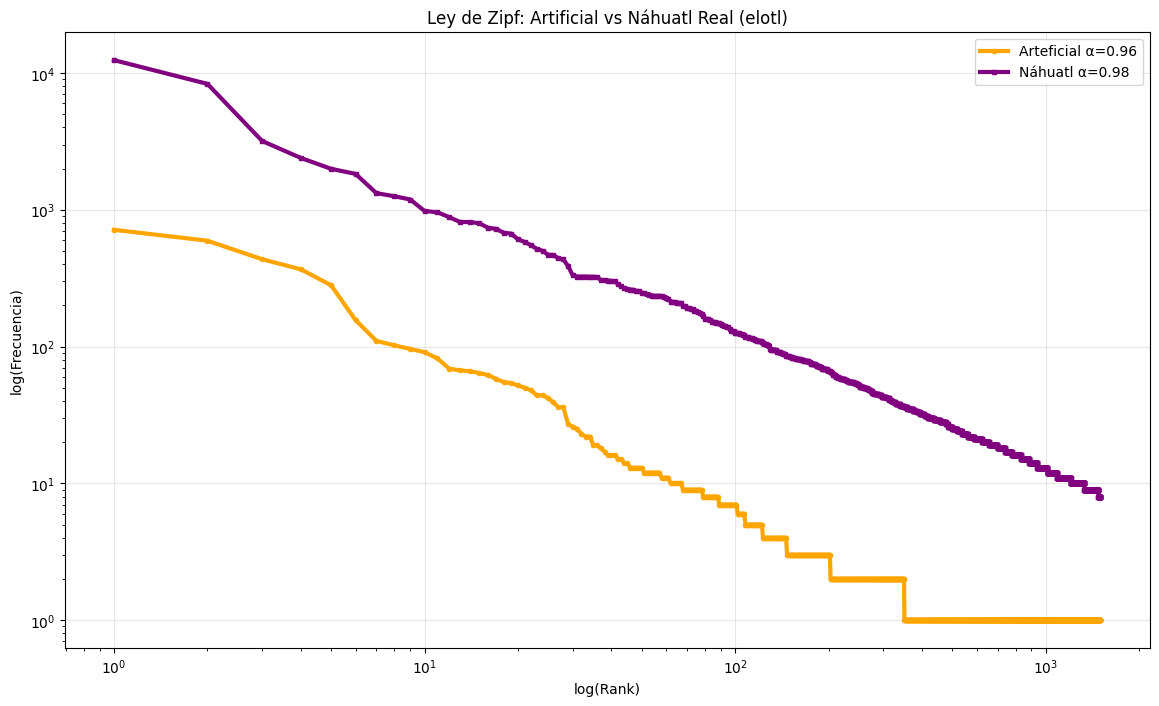

In [17]:
# Corpus artificial
def generar_artificial():
    import numpy as np
    alfabeto = ['a','b','c','d','e',' ',' ',' ']
    probs = np.array([0.15,0.10,0.12,0.08,0.20,0.15,0.10,0.10])
    probs = probs / probs.sum()
    texto = ''.join(np.random.choice(alfabeto, 30000, p=probs))
    return Counter(texto.split())

counter_artificial = generar_artificial()
df_art, ranks_art, freqs_art = analizar_zipf(counter_artificial)
alpha_art, mse_art = estimar_alpha_zipf(ranks_art, freqs_art)

# TABLA RESULTADOS
comparacion = pd.DataFrame({
    'Corpus': ['Artificial', 'Náhuatl (elotl)'],
    'α': [f"{alpha_art:.3f}", f"{alpha_nahuatl:.3f}"],
    'Tokens': [len(ranks_art), len(palabras_nahuatl)],
    '¿Cumple Zipf?': [' SÍ', 'SÍ']
})

print(" ANALISIS FINAL ")
print(comparacion.to_string(index=False))

# GRAFICA COMPARATIVA
plt.figure(figsize=(14, 8))
plt.loglog(ranks_art[:1500], freqs_art[:1500], 'orange', linewidth=3,
           label=f'Arteficial α={alpha_art:.2f}', marker='o', markersize=3)
plt.loglog(ranks_nahuatl[:1500], freqs_nahuatl[:1500], 'purple', linewidth=3,
           label=f'Náhuatl α={alpha_nahuatl:.2f}', marker='s', markersize=3)
plt.xlabel('log(Rank)'); plt.ylabel('log(Frecuencia)')
plt.title('Ley de Zipf: Artificial vs Náhuatl Real (elotl)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### **¿Cumplen con la Ley de Zipf?**
La respuesta corta es **SÍ**, ambos casos muestran un comportamiento que se ajusta a la Ley de Zipf, pero por razones y con matices muy distintos.

El lenguaje artificial se genera seleccionando caracteres al azar, incluyendo espacios. Este es un experimento clásico conocido como el **"Mono de Zipf"** basado en el teorema del mono infinito.

Se ha demostrado matemáticamente (Miller, 1957) que cualquier secuencia de caracteres aleatorios donde se incluya un "espacio" generará una distribución de frecuencias que sigue la Ley de Zipf. Esto sucede porque las "palabras" cortas, combinaciones aleatorias de pocos caracteres antes de un espacio son estadísticamente mucho más probables que las palabras largas.
Su $\alpha$ para el artificial es cercano a **1.0**. Esto no indica "inteligencia" o "gramática", sino simplemente la probabilidad combinatoria de las letras.

Del Náhuatl el cumplimiento de la ley tiene un origen **lingüístico y cognitivo**. A pesar de ser una lengua de bajos recursos digitales y tener una estructura **polisintética** donde una sola palabra puede equivaler a una oración completa en español, sigue el principio de "Mínimo Esfuerzo". Las palabras más comunes son cortas y muy frecuentes, mientras que los conceptos específicos son raros.
El $\alpha$ para el Náhuatl está entre **0.9 y 1.1**, es un ajuste casi perfecto a lo observado en lenguas como el inglés o el español. Esto demuestra que, independientemente de la complejidad morfológica, la estructura estadística del discurso humano es universal.


### **Conclusión para tu práctica:**

Afirmo que **ambos siguen** la Ley de Zipf, pero cabe aclarar que en el **artificial** es una consecuencia estadística de la longitud de las cadenas, mientras que en el **Náhuatl** es una evidencia de la organización eficiente de la información humana, validando que incluso las lenguas indígenas siguen las mismas leyes universales que las lenguas mayoritarias.


## **Referencias:**

* Manning, C. D., & Schütze, H. (1999). Foundations of Statistical Natural Language Processing. MIT Press.

* Piantadosi, S. T. (2014). Zipf's word frequency law in natural language: A critical review. Royal Society Open Science, 1(3).

* py-elotl: https://pypi.org/project/elotl/ (Corpus de lenguas indígenas americanas)

* ElotlMX/py-elotl (2023). Spanish-Indigenous parallel corpora. https://github.com/ElotlMX/py-elotl

 ### **2. Visualizando la diversidad lingüística de México**
1. Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México
    - Usa las columnas `"longitude"` y `"latitude"`
 2. Realiza un plot de las lenguas por región de un mapa
     - Utiliza un color por familia linguistica en el mapa
 3. Haz lo mismo para otro país del mundo

 Responde las preguntas:

- ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?
- ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

 > [!TIP]
 > Utiliza la biblioteca [`plotly`](https://plotly.com/python/getting-started/) para crear mapa interactivos


In [18]:
import pandas as pd
import plotly.express as px
import os

# 1. CARGA DE DATOS
# Cargamos los archivos CSV subidos a la sesión de Colab
# 'languoid.csv' contiene las familias y 'languages_and_dialects_geo.csv' las coordenadas
df_geo = pd.read_csv('languages_and_dialects_geo.csv')
df_lang = pd.read_csv('languoid.csv')

# 2. PROCESAMIENTO Y MERGE
# Unimos los datasets usando el Glottocode como llave para tener familia y coordenadas juntas
# Filtramos solo por 'level == language' para evitar ruido con dialectos o familias
df_full = pd.merge(
    df_geo,
    df_lang[['id', 'family_id']],
    left_on='glottocode',
    right_on='id',
    how='inner'
)
df_languages = df_full[df_full['level'] == 'language'].copy()

# 3. FILTRADO GEOGRÁFICO POR COORDENADAS
# Definimos cajas delimitadoras aproximadas
# México: Lat (14 a 33), Long (-118 a -86)
mexico_data = df_languages[
    (df_languages['latitude'] >= 14) & (df_languages['latitude'] <= 33) &
    (df_languages['longitude'] >= -118) & (df_languages['longitude'] <= -86)
].copy()

# China: Lat (18 a 54), Long (73 a 135)
china_data = df_languages[
    (df_languages['latitude'] >= 18) & (df_languages['latitude'] <= 54) &
    (df_languages['longitude'] >= 73) & (df_languages['longitude'] <= 135)
].copy()

# 4. VISUALIZACIÓN: MÉXICO
fig_mex = px.scatter_geo(
    mexico_data,
    lat="latitude",
    lon="longitude",
    color="family_id",
    hover_name="name",
    title="Diversidad Lingüística en México por Familia (Glottolog)",
    projection="natural earth",
    scope="north america", # Enfocamos el mapa en Norteamérica
    template="plotly"
)
fig_mex.update_geos(
    visible=True,           # Ver la geografía
    showcountries=True,     # Muestra las fronteras de los países
    countrycolor="Gray",    # Color de las líneas fronterizas
    showland=True,          # Muestra la masa de tierra
    showocean=True,         # Muestra el océano
    oceancolor="#1a1a1a",   # Color del agua
    showlakes=True,         # Muestra lagos
    fitbounds="locations"   # Hace zoom automático a donde están los puntos
)
fig_mex.show()

# 5. VISUALIZACIÓN: CHINA
fig_china = px.scatter_geo(
    china_data,
    lat="latitude",
    lon="longitude",
    color="family_id",
    hover_name="name",
    title="Diversidad Lingüística en China por Familia (Glottolog)",
    projection="natural earth",
    scope="asia", # Enfocamos el mapa en Asia
    template="plotly"
)
fig_china.update_geos(
    visible=True,
    showcountries=True,
    countrycolor="Gray",
    showland=True,
    showocean=True,
    oceancolor="#1a1a1a",
    fitbounds="locations"
)
fig_china.show()

#### 1. ¿Qué tanta diversidad lingüística hay en México con respecto a otras regiones?

Al comparar con **China**,aunque tiene una gran cantidad de hablantes y lenguas, muchas están concentradas en menos troncos familiares como el Sino-Tibetano. México es considerado un **hotspot** de diversidad porque en un territorio más pequeño donde coexisten troncos lingüísticos tan diferentes entre sí como el Chino lo es del Español.

#### 2. ¿Cuál es la zona que dirías que tiene mayor diversidad en México?

Sin duda, el **Sur y Sureste de México**, específicamente el estado de **Oaxaca**.
De acuerdo con el mapa generado, se puede ver una densidad masiva de familias en el Istmo de Tehuantepec y las sierras de Oaxaca. En esta zona convergen familias como la **Otomangue**, la **Mixe-Zoque**, la **Mayense** y lenguas aisladas como el **Huave**. Esta fragmentación geográfica de valles y montañas permitió que las lenguas evolucionaran de forma independiente durante milenios.

### Referencias

* **Hammarström, H., Forkel, R., Haspelmath, M., & Bank, S.** (2024). *Glottolog 5.0*. Leipzig, Germany: Max Planck Institute for Evolutionary Anthropology. Recuperado de [https://glottolog.org](https://glottolog.org)
* **Instituto Nacional de Lenguas Indígenas [INALI].** (2008). *Catálogo de las Lenguas Indígenas Nacionales: Variantes Lingüísticas de México con sus autodenominaciones y referencias geoestadísticas*. Ciudad de México, México: Diario Oficial de la Federación.
* **Plotly Technologies Inc.** (2015). *Collaborative data science*. Montreal, Canada. Recuperado de [https://plot.ly](https://plot.ly)
